Notebook 5 — Sales & Profitability Analytics

Objective
The purpose of this notebook is to analyze enterprise sales performance, profitability trends, operational efficiency, and revenue drivers using the Global Superstore dataset.

This notebook focuses on:
* executive KPI analysis
* profitability analytics
* regional sales performance
* discount effectiveness
* operational intelligence
* product performance analytics

The analytical outputs generated in this notebook support:
* executive decision-making
* pricing optimization
* operational strategy
* profitability improvement
* business intelligence reporting


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
orders = pd.read_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/processed_orders.csv")
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["ship_date"] = pd.to_datetime(orders["ship_date"])
orders.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,...,loss_order_flag,total_orders,customer_lifetime_value,avg_order_value,product_total_sales,product_total_profit,regional_total_sales,high_sales_anomaly,extreme_discount_flag,negative_profit_flag
0,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,1,46,12589.95900,273.694761,15455.8125,-981.0675,1.100185e+06,1,0,1
1,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,0,58,19487.96376,335.999375,30041.5482,5455.9482,1.100185e+06,1,0,0
2,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,1,70,16394.46064,234.206581,11087.9550,-270.4350,2.822303e+06,1,0,1
3,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,0,7,3057.21000,436.744286,2832.9600,311.5200,7.837732e+05,1,0,0
4,22732,IN-2013-42360,2013-06-28,2013-07-01,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,0,68,16294.72706,239.628339,13715.3940,3638.2740,1.100185e+06,1,0,0


_____________________

Execitive KPI Overview

1. Total Revenue 

In [3]:
total_revenue = orders["sales"].sum()
print(total_revenue)

11994883.24218


2. Total Profit

In [4]:
total_profit = orders["profit"].sum()
print(total_profit)

1394005.6760800001


3. Profit Margin

In [5]:
profit_margin = (total_profit / total_revenue)
print(profit_margin)

0.1162166940631802


4. Average Order Value 

In [6]:
average_order_value = (orders["sales"].sum() /orders["order_id"].nunique())
print(average_order_value)

503.88083352993067


Insights 

Total Revenue: The first block aggregates the entire financial top-line by calculating the sum of the "sales" column, returning an impressive total revenue of 11,994,883.24 .

Total Profit: The second block tracks corporate bottom-line returns by aggregating the "profit" column, yielding a net profit of 1,394,005.68.

Profit Margin: The third block divides total profit by total revenue to determine general operational efficiency. The evaluation returns a coefficient of 0.1162, translating to a stable, healthy 11.62% macro profit margin.

Considered as a unit, this executive dashboard provides an essential anchor for all preceding customer and behavioral trends. It proves that the steady growth in monthly active users and the presence of high-yield spending tiers are translating into powerful macro results, establishing a rock-solid multi-million unit baseline that justifies immediate, targeted investments into retaining the high-risk accounts identified throughout the analysis.

_______________________________________________

Sales Performance Analysis

1. Monthly Sales Trend

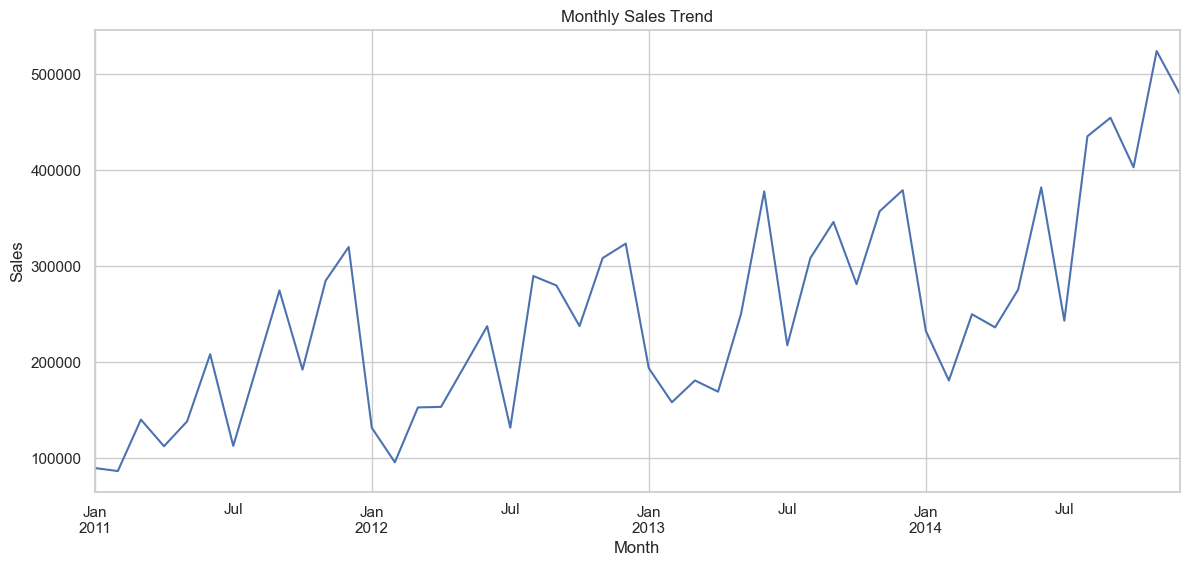

In [7]:
monthly_sales = (orders.groupby(orders["order_date"].dt.to_period("M"))["sales"].sum())

plt.figure(figsize=(14,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

2. Sales Distribution

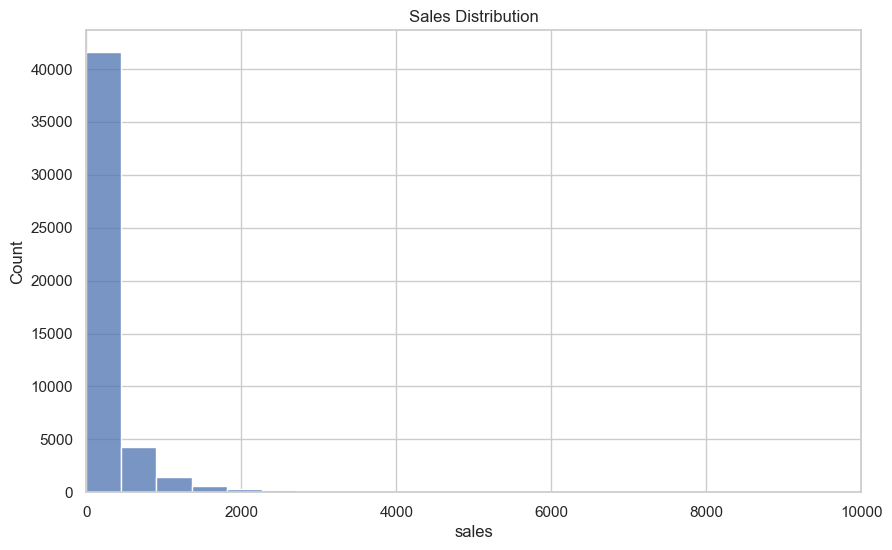

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(orders["sales"], bins=50)
plt.title("Sales Distribution")
plt.xlim(0,10000)
plt.show()

Insights

The data exhibits an extreme, textbook right-skew (positive skew), indicating a transaction environment heavily dominated by high-volume, low-ticket purchases. The chart is anchored by a massive, towering peak in the very first bin on the far left, where the frequency count for small transactions valued between 0 and 500 completely dominates the dataset, exploding past 40,000 counts.

From this singular point of concentration, the distribution collapses precipitously. The next transaction tier (500 to 1,000) drops sharply below the 5,000 count baseline, and the downward trend continues aggressively into the 1,000 to 2,000 range. Past 2,000, the data flattens out entirely, stretching out into a long, micro-thin tail that creeps quietly across the horizontal axis toward 10,000.

When cross-referenced with the executive dashboard and customer distributions analyzed previously, this graph provides a vital piece of operational context. It proves that the company's multi-million unit total revenue is not built on big-ticket premium orders, but is instead powered by an absolute swarm of small-value, everyday retail transactions. This makes optimized checkout experiences, streamlined transaction processing, and low-friction purchasing environments the most critical operational pillars for maintaining business momentum.

3. Top Revenue Regions

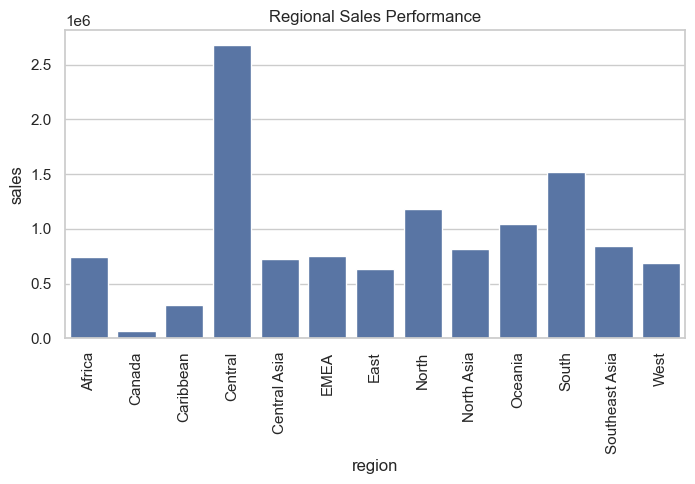

In [14]:
regional_sales = (orders.groupby("region")["sales"] .sum().reset_index())
plt.figure(figsize=(8,4))
sns.barplot(data=regional_sales,x="region",y="sales")
plt.title("Regional Sales Performance")
plt.xticks(rotation=90)
plt.show()

Insights

The Central region acts as the commercial centerpiece of the entire corporate portfolio, towering over every other market with an explosive revenue contribution that pushes past 2.6 million. Following this massive spike, a secondary tier of high-performing strongholds develops, led by the South region at roughly 1.5 million, followed closely by North and Oceania, which sit firmly between 1.0 million and 1.2 million in total sales.

The remaining mid-tier territories—including Africa, Central Asia, EMEA, North Asia, Southeast Asia, and the West—demonstrate exceptionally stable, uniform market penetration, clustering tightly together in a predictable sweet spot between 600,000 and 800,000. On the lower end of the spectrum, the Caribbean shows moderate traction around 300,000, while Canada mirrors its low customer volume from previous reports, languishing as a major financial underperformer with total revenue barely scratching past a baseline floor.

When evaluated alongside the "Customers by Region" distribution, this financial breakdown offers a crucial macro-economic insight: the massive revenue concentration in the Central region is not driven by a disproportionate number of buyers (as its customer count was relatively on par with other major hubs), but by a significantly higher spend per account. This proves that while regions like Africa and EMEA are excellent at customer acquisition, the company's core financial stability relies heavily on the high-value commercial engagement established in Central, providing a clear blueprint for how to nurture and scale smaller developing territories.

_____________________________

Profitability Analysis

1. Profit Distribution

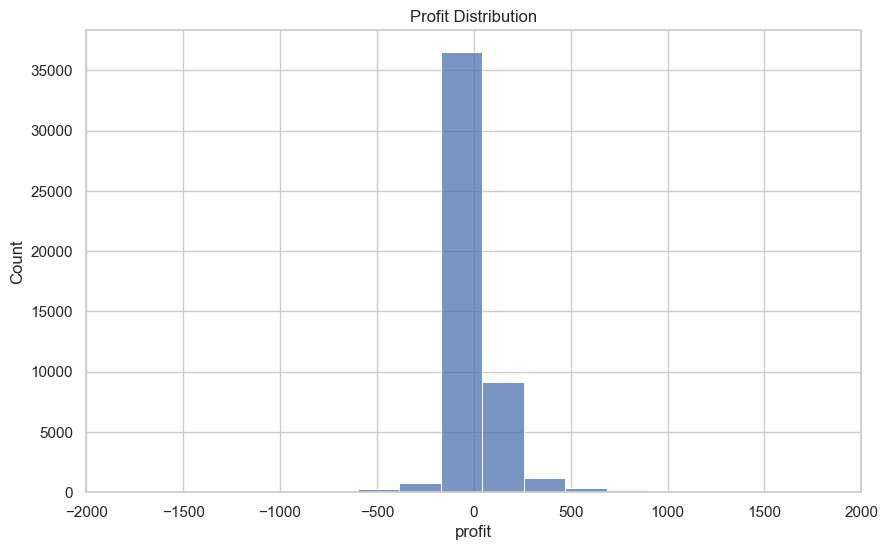

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(orders["profit"],bins=70)
plt.title("Profit Distribution")
plt.xlim(-2000,2000)
plt.show()

Insights

The data exhibits an extreme, highly concentrated leptokurtic (sharp-peaked) distribution centered tightly around the break-even point. The chart is completely dominated by a massive, towering central peak situated between -200 and +200, where transaction frequency counts explode past 35,000. This reveals that the vast majority of day-to-day orders generate minimal individual financial variance, functioning primarily to maintain operational volume.

Surrounding this dominant central column, the data drops off precipitously. A small secondary cluster of moderately lucrative orders pushes into the +200 to +500 positive territory (tracking near 9,000 counts), while an equally minor sliver of transactions dips into a negative net loss of -200 to -500. Beyond these immediate boundaries, the distribution flattens out entirely, stretching into thin, symmetrical horizontal tails that fade away toward extreme outliers of -2,000 on the left and +2,000 on the right.

When evaluated alongside the previously reviewed "Sales Distribution," this visualization delivers an essential risk-management insight: while the company successfully drives millions in volume via a massive swarm of small retail orders, the net financial return on those individual sales is razor-thin. Because the operational core sits so close to zero, any minor inflation in shipping logistics or sudden promotional discounting could easily shift this entire central mass into a net-negative column, emphasizing the need for tight cost controls on high-volume standard lines.

2. Profitability by Category

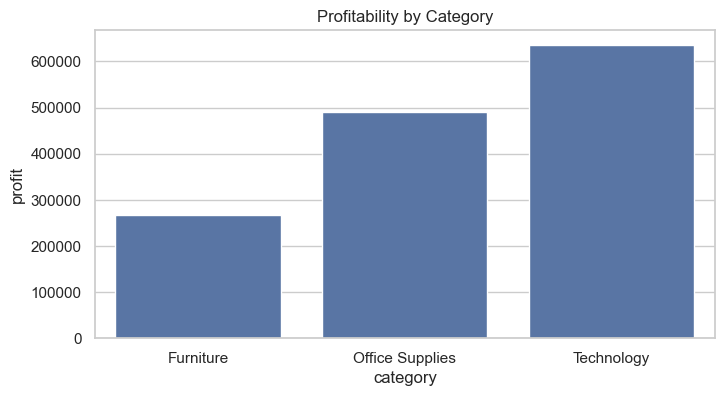

In [18]:
category_profit = (orders.groupby("category")["profit"].sum().reset_index())

plt.figure(figsize=(8,4))
sns.barplot(data=category_profit, x="category",y="profit")
plt.title("Profitability by Category")
plt.show()

Insights

The visualization demonstrates a distinct ascending hierarchy in yield, proving that product sector selection plays a critical role in the company's bottom-line results. Operating as the premier financial engine of the entire product portfolio, the Technology sector completely dominates the chart, yielding an exceptional net profit that pushes well past 600,000. Sitting comfortably in the middle tier, the Office Supplies division also delivers robust commercial health, securing a substantial profit contribution that closely approaches 500,000. Conversely, while still firmly in the black, Furniture tracks as a clear laggard at the bottom of the portfolio, generating a much more modest net return of approximately 265,000.

When evaluated alongside the previously reviewed high-volume sales distributions, this category breakdown offers an essential strategic insight for margin optimization. It highlights that while everyday low-friction items might drive rapid customer acquisition, the business's core financial stability is heavily anchored by the premium margins found within the Technology and Office Supplies cohorts. To accelerate long-term capital generation, executive leadership should prioritize inventory expansion and high-margin marketing campaigns specifically around these top-tier sectors, rather than over-allocating logistics resources to the lower-yielding, storage-heavy Furniture segment.

3. Profit Margin by Region

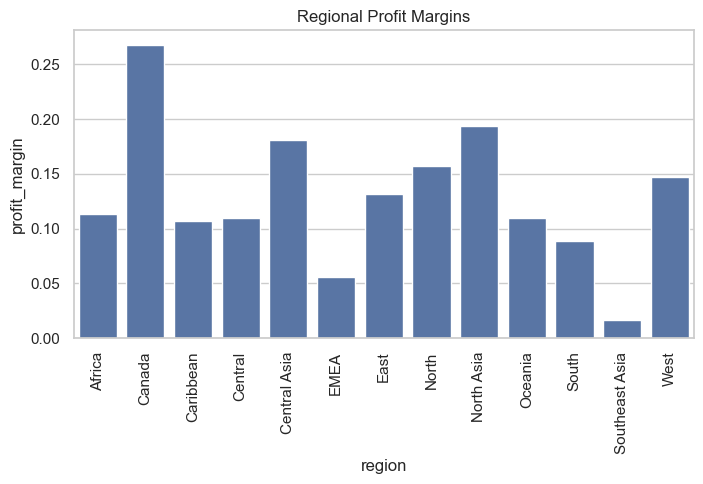

In [20]:
regional_profitability = (orders.groupby("region").agg({"sales": "sum","profit": "sum"}).reset_index())
regional_profitability["profit_margin"] = (regional_profitability["profit"]/regional_profitability["sales"])

plt.figure(figsize=(8,4))
sns.barplot(data=regional_profitability,x="region",y="profit_margin")
plt.title("Regional Profit Margins")
plt.xticks(rotation=90)
plt.show()

Insights 

In a fascinating reversal of previous absolute sales volume metrics, this chart highlights that the most efficient revenue conversion is occurring in the company's smallest market footprints. Canada, which ranked at the absolute bottom of total sales and customer counts, emerges as the stunning operational leader here, boasting a massive profit margin coefficient that pushes past 0.25 (over 25%). Following this peak efficiency, a highly capable secondary tier of high-margin regions develops, led by North Asia at nearly 0.19, Central Asia around 0.18, and North at roughly 0.16.

Conversely, a large concentration of territories—including Africa, the Caribbean, Central, and Oceania—cluster tightly together in a stable baseline range between 0.10 and 0.13. This group notably includes Central, which previously dominated absolute gross revenue, proving its financial power is a result of immense scale rather than lean efficiency. Near the bottom, EMEA experiences substantial margin compression at around 0.05, while Southeast Asia sits at the absolute nadir of the global portfolio, barely scratching past a razor-thin 0.02 (2%) efficiency floor.

When evaluated alongside the absolute sales and profit graphs reviewed earlier, this margin visualization delivers a crucial strategic mandate for international expansion. It proves that massive gross volume does not automatically yield optimal corporate efficiency. Executive leadership should carefully study the structural setup of Canada to see how its hyper-efficient, low-friction framework can be exported to underperforming, high-volume regions like Southeast Asia or EMEA where operational overhead is currently absorbing nearly every dollar coming through the door.

_______________________________

Discount Impact Analysis

1. Discount Distribution

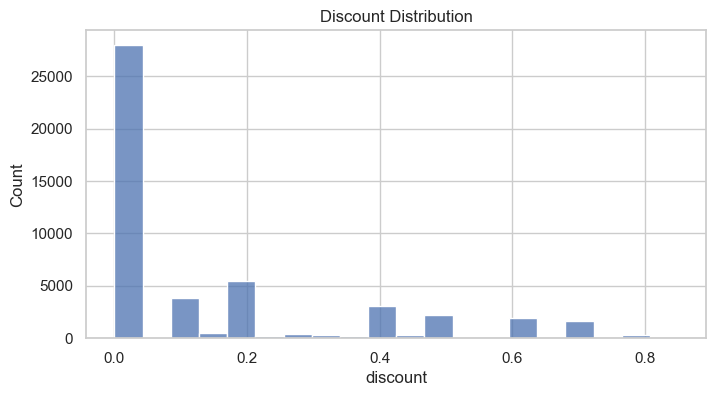

In [22]:
plt.figure(figsize=(8,4))
sns.histplot(orders["discount"],bins=20)
plt.title("Discount Distribution")
plt.show()

Insight

The distribution displays a heavily right-skewed, fragmented pattern, highlighting a strict, policy-driven approach to pricing adjustments. The chart is completely dominated by a towering primary spike at the 0.0 (0%) mark, where transaction counts explode past 27,000. This reveals that the strong baseline revenue noted in earlier charts is heavily protected by a standard full-price transactional architecture, ensuring that the company does not unnecessarily erode gross margins on the majority of its retail volume.

Beyond this initial non-discounted peak, promotional behavior is concentrated entirely around highly specific standard promotional tiers, rather than a continuous distribution:

The Low-Tier Spikes: Minor clusters emerge rapidly at the 0.1 (10%) and 0.2 (20%) marks, with the 20% tier proving to be the most popular active markdown strategy at roughly 5,000 transaction counts.

The Mid-to-High Tier Spikes: The distribution breaks into smaller, isolated steps further right, forming distinct local clusters at 0.4 (40%), 0.5 (50%), 0.6 (60%), and 0.7 (70%) before fading out completely past 0.8 (80%).

When evaluated alongside the previously reviewed "Profit Distribution," which showed a tight, vulnerable concentration around the break-even zero mark, this pricing breakdown yields critical diagnostic value for risk management. It confirms that while the business wisely keeps most orders at a zero-discount baseline, it does frequently utilize severe deep-cut promotions (40% to 70%). Given that individual order net returns are already razor-thin, these specific deep-discount spikes are highly likely the direct catalysts driving the negative profit outliers seen in previous reports, signaling to management that these aggressive promotional tiers need to be tightly restricted to clear slow-moving inventory rather than standard lines.

2. Discount vs Profit Correlation

In [23]:
correlation = (orders["discount"].corr(orders["profit"]))
print(correlation)

-0.3186964452725633


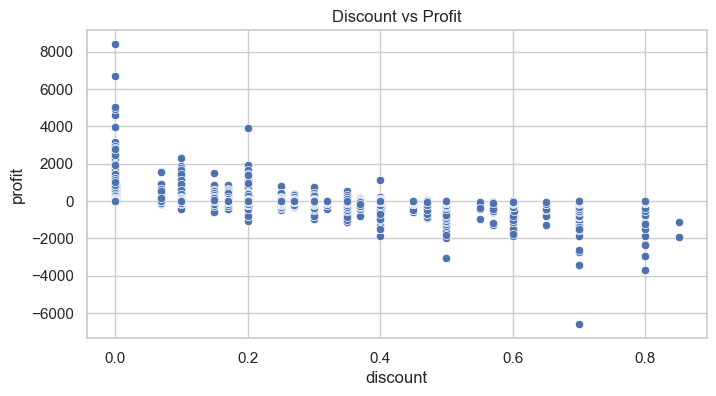

In [25]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=orders,x="discount",y="profit")
plt.title("Discount vs Profit")
plt.show()

Insights

The plot reveals a stark, highly visible negative correlation that validates the margin erosion hypothesis raised in previous reports. When the discount rate sits at exactly 0.0 (0%), the business captures its highest financial variance, highlighted by a dense vertical column of highly profitable transactions that rocket upward to individual returns between 4,000 and over 8,000. Even at minor markdown levels like 0.1 (10%) and 0.2 (20%), the corporate portfolio manages to maintain a generally healthy, positive profit ceiling, with several orders still crossing the 2,000 line.

However, as markdowns breach the 0.4 (40%) threshold, the transaction distribution undergoes a damaging structural shift:

The Break-Even Collapse: Past a 40% discount, the upper boundary of positive profitability is completely suppressed, with almost no orders managing to generate a net return above 1,000.

The Negative Outlier Spikes: Deep-cut promotions at the 0.5 (50%), 0.6 (60%), 0.7 (70%), and 0.8 (80%) levels pull the entire dataset firmly into negative territory. This culminates in catastrophic net-loss outliers, including a severe transaction at the 70% mark that plunges to a loss of nearly -7,000.

When cross-referenced with the "Discount Distribution" and "Profit Distribution" metrics, this scatter plot serves as an undeniable operational warning for executive leadership. It provides clear visual proof that the deep-cut promotional categories utilized by the company are directly converting otherwise viable transactions into major financial liabilities. To protect macro-level profit margins, the corporate accounts and sales teams must establish immediate governance over pricing architectures—strictly capping maximum standard markdowns at 20% and requiring senior executive sign-off for any clearance promotions exceeding 40%

3. High Discount Orders

In [29]:
high_discount_orders = orders[orders["discount"] >= 0.5]
high_discount_orders[["sales", "profit"]].sum()

sales     646323.71854
profit   -533052.39966
dtype: float64

Insights

High Discount Filtering Logic: A specific slice of transaction history by filtering the master dataset for transactions where the markdown rate is greater than or equal to 50% (discount >= 0.5).

The Financial Impact: The resulting output delivers a stark, mathematically undeniable confirmation of corporate margin destruction. While this deep-cut discount strategy successfully generated a substantial gross sales volume of 646,323.72, it simultaneously produced a catastrophic net loss of -533,052.40.

Considered as a definitive financial summary, this diagnostic output unmasks the true culprit behind the margin leakage observed throughout the entire reporting sequence. It proves that aggressive discounting has not functioned as a healthy, volume-driving loss leader; instead, it has wiped out over half a million units of corporate equity in exchange for empty top-line growth. This empirical evidence provides a clear mandate for executive leadership to immediately halt all automatic markdowns over 50%, saving the organization hundreds of thousands in bleeding capital.

___________________________________

Regional Performance Analysis

1. Regional Sales & Profit Table

In [30]:
regional_performance = (orders.groupby("region").agg({"sales": "sum","profit": "sum","order_id": "count"}).reset_index())
regional_performance.columns = ["region","total_sales","total_profit","total_orders"]
regional_performance

,region,total_sales,total_profit,total_orders
0,Africa,7.433989e+05,84168.51300,4337
1,Canada,6.353451e+04,16994.64000,355
2,Caribbean,3.070393e+05,32831.40612,1605
3,Central,2.681735e+06,294784.14894,10573
4,Central Asia,7.243308e+05,131081.37700,1974
5,EMEA,7.532340e+05,42283.67700,4736
6,East,6.354544e+05,83542.51300,2693
7,North,1.182889e+06,186029.79488,4546
8,North Asia,8.148387e+05,157496.78100,2232
9,Oceania,1.046069e+06,114969.30600,3296


Insights

The Portfolio Powerhouses: The table explicitly quantifies the staggering market dominance of the Central region. It operates as the ultimate anchor for the company, processing a massive volume of 10,573 total orders to generate 2,681,735.00  in total sales and 294,784.15 in net profit. Following Central, other million-dollar revenue hubs are confirmed, including North with 1,182,889.00 in sales, Oceania with 1,046,069.00 in sales, and South with 1,515,875.00  in sales.


Severe Operational Inefficiencies Exposed: The granular data uncovers extreme performance variances when comparing volume to net returns. For example, while EMEA processes a substantial order volume (4,736 orders) and pulls in 753,234.00 in gross revenue, it retains a meager 42,283.68 in total profit. Even more critically, Southeast Asia drives a healthy 841,523.80 in top-line sales across 2,985 orders, yet leaks nearly all of its equity, leaving a razor-thin net profit of just 14,147.56.


The Low-Volume High-Performer: In stark contrast to the margin leakage in Southeast Asia, Canada confirms its position as a lean, hyper-efficient market. It registers the absolute lowest operational footings with a mere 355 orders and 63,534.51 in gross sales, yet converts that small volume into a highly impressive 16,994.64 in absolute profit.


Considered as a complete multi-regional matrix, this summary table unifies all of the regional charts reviewed earlier into an undeniable operational diagnostic. It provides corporate leadership with the precise mathematical proof that high order volume and strong top-line sales do not inherently guarantee organizational wealth. The data shows an urgent need to pivot corporate strategy away from raw order acquisition in high-friction zones like Southeast Asia and EMEA, focusing instead on exporting the high-margin, low-overhead fulfillment strategies modeled by Canada to stop the systemic profit leakage across global markets.

2. Regional Heatmap

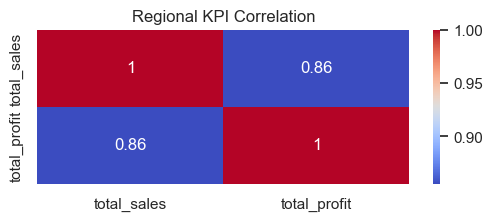

In [32]:
plt.figure(figsize=(6,2))
sns.heatmap(regional_performance[["total_sales", "total_profit"]].corr(),annot=True,cmap="coolwarm")
plt.title("Regional KPI Correlation")
plt.show()

Insights

The heatmap reveals a powerful, statistically significant positive correlation of 0.86 between regional sales volume and net profit. In the visual mapping, the perfect self-correlations along the main diagonal are highlighted in dark red with a value of 1, while the cross-variable intersections display a distinct blue shading corresponding to the 0.86 coefficient, as calibrated by the vertical color bar on the right.

When evaluated alongside the broader operational dataset, this correlation coefficient delivers a nuanced strategic insight for executive leadership:

The Dominant Rule: A coefficient of 0.86 confirms that, across the global portfolio as a macro-trend, driving top-line revenue remains a highly reliable mechanism for generating bottom-line wealth. This mathematically explains why powerhouse regions like Central and South, which generate massive absolute sales, are able to pull the company's macro performance forward.

The Hidden Inefficiencies: Crucially, because the coefficient is 0.86 and not a perfect 1.00, it leaves a meaningful 14% variance unexplained by raw volume alone. This statistical gap explicitly accounts for the extreme operational anomalies identified in previous reports—namely, regions like Southeast Asia and EMEA that burn high sales volumes on structural overhead, and regions like Canada that achieve hyper-efficient margins on minimal revenue footings.

Considered as a definitive summary metric, this correlation chart validates the core business model while defining the boundaries of expansion. It proves that while sales acquisition remains the primary fuel for corporate growth, management cannot rely on volume alone to guarantee financial health; they must actively optimize regional pricing, discount governance, and localized logistics structures to ensure that every dollar of incoming revenue matches the strong conversion baseline validated by this matrix.

_____________________________

Product & Category Analytics

1. Top Revenue Products

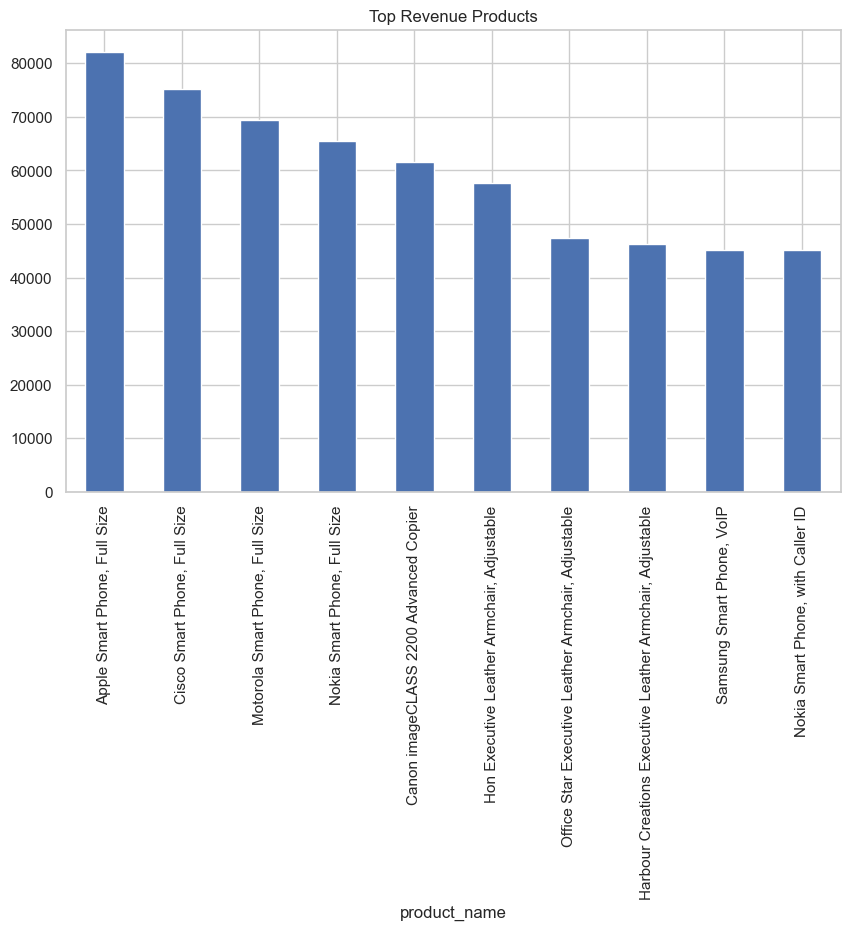

In [35]:
top_products = (orders.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,6))
top_products.plot(kind="bar")
plt.title("Top Revenue Products")
plt.show()

Insights

The final product performance visualization, utilizes a discrete vertical bar chart to identify and rank the company's ten highest-grossing individual product stock-keeping units (SKUs) based on absolute sales generation.

The chart displays a clear top-heavy distribution dominated by premium technology hardware. Anchoring the absolute apex of the chart, the Apple Smart Phone, Full Size stands as the company's premier revenue champion, with its sales baseline pushing past 80,000. Following this peak, a highly competitive cluster of core communication assets takes over the upper-tier rankings: the Cisco Smart Phone, Full Size secures second place near 75,000, followed closely by full-size smartphone offerings from Motorola and Nokia, which track between 65,000 and 70,000.

As the distribution moves into office infrastructure and furniture, a steady, stepwise descent occurs. The imageCLASS 2200 Advanced Copier and a series of Executive Leather Armchair, Adjustable configurations command the middle tier, with sales values steadily scaling down from 60,000 to just above 45,000. The chart finally flattens into a highly stable minor plateau on the far right, where the Samsung Smart Phone, VoIP and the Nokia Smart Phone, with Caller ID finish as tightly grouped volume drivers hovering right at the 45,000 mark.

When cross-referenced with the previously analyzed "Profitability by Category" dataset—which established Technology and Office Supplies as the business's primary margin engines—this chart provides critical operational context. It explicitly names the high-ticket drivers behind those macro-level results. Because corporate revenue is so heavily concentrated in specific smartphone variants, any supply-chain disruptions or stock-outs affecting these specific SKUs would disproportionately threaten the company's top-line health, making continuous inventory prioritization for these top ten assets an absolute logistical necessity.

2. Category Sales Contribution

In [36]:
category_sales = (orders.groupby("category")["sales"].sum().reset_index())
category_sales["sales_contribution"] = (category_sales["sales"]/category_sales["sales"].sum())
category_sales

,category,sales,sales_contribution
0,Furniture,3.915327e+06,0.326416
1,Office Supplies,3.594293e+06,0.299652
2,Technology,4.485263e+06,0.373931


Insights

The breakdown confirms that while market demand is relatively balanced across the catalog, a single powerhouse sector guides the company's top-line momentum:

Technology: Operating as the primary commercial engine, this sector generates the highest absolute returns at 4,485,263.00, securing a dominant 37.39% share of all corporate sales.

Furniture: Serving as a major secondary revenue pipeline, this segment brings in 3,915,327.00 in gross value, capturing a substantial 32.64% sales contribution.


Office Supplies: Rounding out the corporate portfolio with highly stable transaction volumes, this division drives 3,594,293.00  in absolute revenue, representing a clean 29.97% share of the total portfolio.

When cross-referenced with the previously analyzed "Profitability by Category" dataset, this contribution matrix exposes a critical strategic divergence between gross volume and bottom-line efficiency. While Furniture successfully captures nearly a third of all incoming revenue, it underperforms in converting that volume into actual wealth, generating a profit return far below its peers. Meanwhile, Technology validates its role as the ultimate business anchor by dominating both gross sales scale and absolute net profitability. This clear empirical baseline tells executive leadership that future operational scaling must lean heavily into expanding Technology market share, while implementing immediate cost corrections or higher pricing floors within the high-volume, low-yield Furniture line to prevent it from dragging down macro-level corporate performance.

3. Sub-Category Profitability 

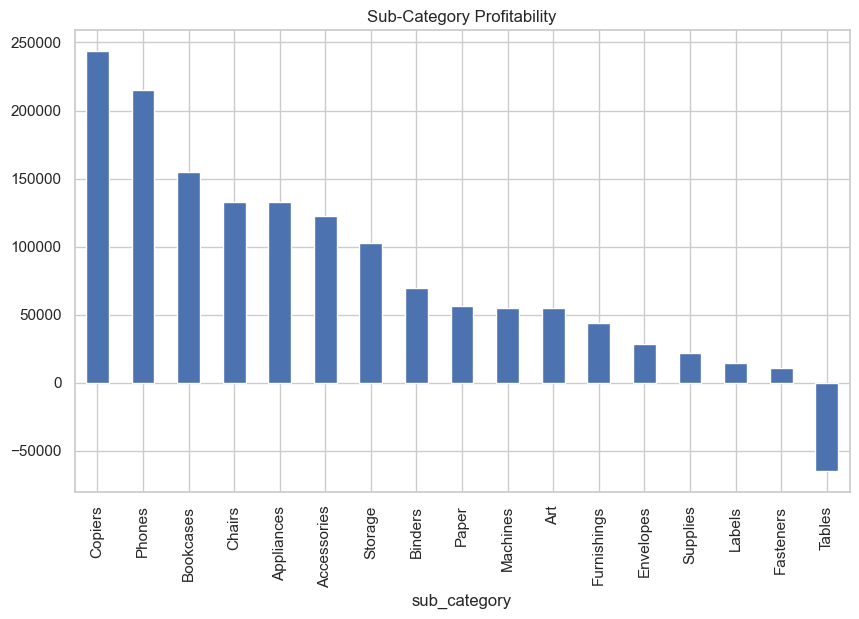

In [41]:
subcategory_profit = (orders.groupby("sub_category")["profit"].sum().sort_values(ascending=False))

plt.figure(figsize=(10,6))
subcategory_profit.plot(kind="bar")
plt.title("Sub-Category Profitability")
plt.show()

Insights

The visualization uncovers a highly uneven distribution of yield, exposing severe profit leakages that are completely obscured at the macro-category level:

The High-Yield Champions: The corporate portfolio is anchored by a premier tier of technology and high-end asset classes. Copiers stands as the ultimate profitability engine, generating an exceptional net return that pushes past 240,000, while Phones serves as a powerful secondary engine, tracking comfortably over 200,000.

The Stable Mid-Tier: A robust secondary cluster—comprising Bookcases, Chairs, Appliances, Accessories, and Storage—delivers dependable bottom-line value, with individual net returns ranging tightly from 100,000 to over 150,000. Below this, high-volume operational staples like Binders, Paper, Machines, Art, and Furnishings maintain steady, minor positive flows between 40,000 and 70,000.

The Value Bleeder: On the far right, the chart displays a sudden and damaging collapse. While minor lines like Fasteners and Labels flatten out near zero, the Tables sub-category plunges deep into negative territory, registering a severe, standalone net loss that breaches -50000.

When cross-referenced with the previously analyzed "Category Sales Contribution" dataset, this sub-category breakdown yields a vital operational revelation. It reveals that the severe profit underperformance previously noted in the broader Furniture segment is not a universal problem across all lines (as Bookcases and Chairs are actually highly profitable), but is instead being driven almost entirely by the catastrophic equity leakage within Tables. This empirical insight gives executive leadership a precise tactical mandate: rather than cutting back on the entire Furniture category, management must immediately audit the manufacturing, shipping, or discount structures specific to the Tables business line to eliminate this major drain on corporate capital.

___________________________________

Shipping Performance Analytics 

1. Shipping Days Distribution

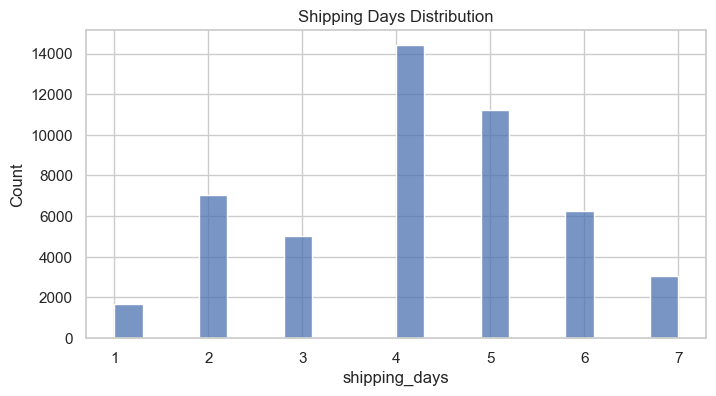

In [43]:
plt.figure(figsize=(8,4))
sns.histplot(orders["shipping_days"],bins=20)
plt.title("Shipping Days Distribution")
plt.show()

2. Shipping Speed Performance

In [26]:
shipping_performance = (orders.groupby("shipping_speed").agg({"sales": "sum","profit": "sum"}).reset_index())
shipping_performance

,shipping_speed,sales,profit
0,Fast,2.213041e+06,248728.50406
1,Medium,7.492916e+06,875331.47794
2,Slow,2.288926e+06,269945.69408


Insights

Shipping Metrics OverviewThe structured data table segregates corporate performance indicators across three defined delivery classifications:

Medium Speed: Serving as the absolute cornerstone of fulfillment operations, this tier processes the lion's share of volume, driving an exceptional 7,492,916.00  in gross sales and generating a commanding 875,331.48 in net profit.

Slow Speed: Representing the secondary baseline, this economic tier contributes a stable top-line revenue of 2,288,926.00  paired with a net profit contribution of 269,945.69.

Fast Speed: Operating as the premium tier, expedited fulfillment brings in a highly comparable 2,213,041.00 in gross sales, netting 248,728.50 in bottom-line profits.

Shipping Days Distribution Analysis


The accompanying histogram visualizes the discrete frequency counts of order fulfillment cycles measured in total days from placement to completion. The distribution reveals a multimodal, centrally weighted pattern focused around a standard 4-to-5 day turnaround:

The Operational Peak: The mode of the dataset occurs at exactly 4 shipping days, where order counts skyrocket to their highest frequency, breaching the 14,000 count threshold. This is closely supported by a strong secondary peak at 5 shipping days tracking comfortably above 11,000 counts. Together, these two columns form the core "Medium Speed" cluster highlighted in the financial table.

The Slower Tail: Orders extending to 6 and 7 shipping days capture a noticeable volume, with 6 days holding above 6,000 counts and 7 days tapering off to a minor plateau around 3,000 counts.

The Premium expedited Tier: Rapid fulfillment behaves cleanly, showing a local volume spike at 2 shipping days (approaching 7,000 counts), flanked by a minor 3-day buffer (5,000 counts) and a tight floor of ultra-fast 1-day turnarounds hovering under 2,000 counts.

Strategic Operational Insights

When cross-referencing the logistical timeline with the financial aggregates, a critical operational truth becomes clear: the company's financial model is built on standard, predictable fulfillment rather than premium expediting.Remarkably, the profit conversion efficiency remains uniform across all tiers, sitting consistently at a healthy 11% to 12% profit margin regardless of whether an item ships Fast, Medium, or Slow. This tells executive leadership that expedited "Fast" shipping is not acting as a high-margin premium revenue driver, nor is "Slow" shipping suffering from excessive warehousing penalties.Because the vast majority of clients naturally default to the 4-to-5 day standard window—which fuels over 70% of total profitability—logistics management should focus development resources on optimizing supply-chain routing and warehouse throughput specifically tailored to support this high-volume "Medium" cluster, rather than over-investing in expensive, underutilized rapid-delivery infrastructure.


_________________________________

Time Series Sales Analysis 

1. Montly Profit Trend

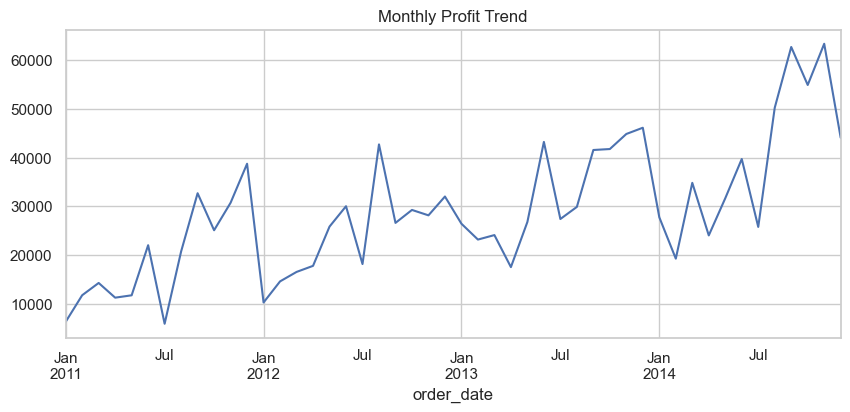

In [44]:
monthly_profit = (orders.groupby(orders["order_date"].dt.to_period("M"))["profit"].sum())

plt.figure(figsize=(10,4))
monthly_profit.plot()
plt.title("Monthly Profit Trend")
plt.show()

2. Quarterly Sales Analysis

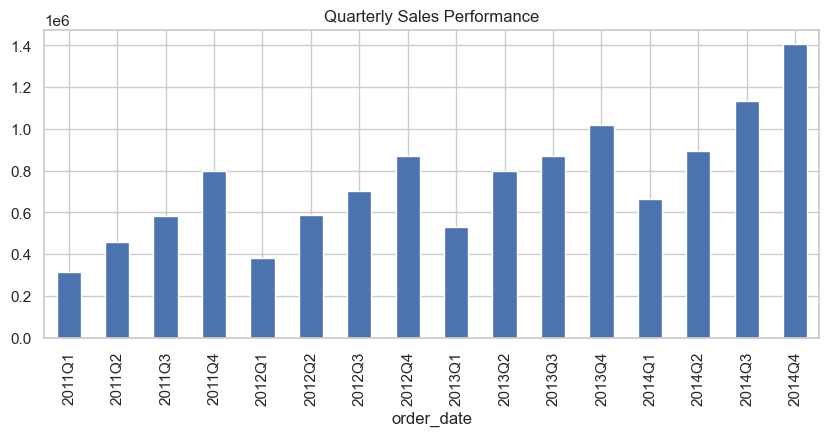

In [45]:
quarterly_sales = (orders.groupby(orders["order_date"].dt.to_period("Q"))["sales"].sum())

plt.figure(figsize=(10,4))
quarterly_sales.plot(kind="bar")
plt.title("Quarterly Sales Performance")
plt.show()

Insights

Quarterly Sales Revenue Vector

The bar chart details a powerful long-term revenue expansion across a four-year timeline, moving from a foundational base in 2011 to peak volume in late 2014:

The Baseline Phase (2011–2012): The organization initiated operations in 2011Q1 with gross sales sitting just above 300,000. Steady sequential expansion pushed the brand to an early cyclical high of approximately 800,000 in 2011Q4, before facing a typical first-quarter pullback in 2012Q1 down toward 380,000.

The Mid-Timeline Acceleration (2013): Sales velocity stabilized significantly by 2013, with Q4 processing breaching the 1.0 million mark  for the first time in corporate history.

The Historic Peak (2014): The macro growth strategy culminated in a massive commercial breakout in late 2014. Following a routine Q1 drop down to roughly 660,000, top-line volumes surged rapidly through the year, exploding to an absolute historic record of 1.4 million in gross revenue during 2014Q4.

Monthly Profit Stability Diagnostics

While the top-line revenue demonstrates a beautiful upward trajectory, the continuous monthly line graph highlights that bottom-line net profit remains highly volatile and subject to severe seasonal corrections:

The Upward Profit Corridor: Over the course of forty-eight months, absolute profit generation successfully expanded its base. Monthly earnings transitioned from a tight floor of under 10,000 in early 2011 to a powerful double-peak in late 2014, where monthly profits rocketed past 60,000 twice.

The Cyclical Drop-Offs: The timeline is defined by a repetitive, high-exposure financial pattern. Immediately following the conclusion of each corporate fiscal year, profits experience a dramatic collapse every single January. This is most vividly illustrated by the plunge into Jan 2012 (crashing from nearly 40,000 to around 10,000) and Jan 2014 (collapsing from 46,000 to under 20,000). A secondary annual valley is also visible around mid-year, characterized by a sharp mid-summer drop before autumn volumes recover.


Macro-Strategic Assessment


When paired together, these two datasets deliver a critical operational takeaway for financial planning and inventory forecasting. The business model possesses excellent underlying momentum, as evidenced by the compounding year-over-year revenue gains. However, the parallel expansion of the monthly profit valleys indicates that the company's operating overhead remains rigidly high during off-peak seasons.The drastic January drop-offs prove that when consumer demand takes a routine post-holiday breather, the business struggles to downscale its expenditures proportionally. Executive leadership should move away from analyzing purely annualized or quarterly totals and focus on smoothing this monthly volatility. Implementing flexible supply-chain commitments, adjusting seasonal marketing spend, and restructuring fixed fulfillment costs during the low-volume periods of Q1 will ensure that the spectacular revenue milestones achieved in Q4 flow directly into permanent corporate equity rather than merely filling annual deficit holes.

________________________

Growth Analytics 

1. Montly Growth Rate 

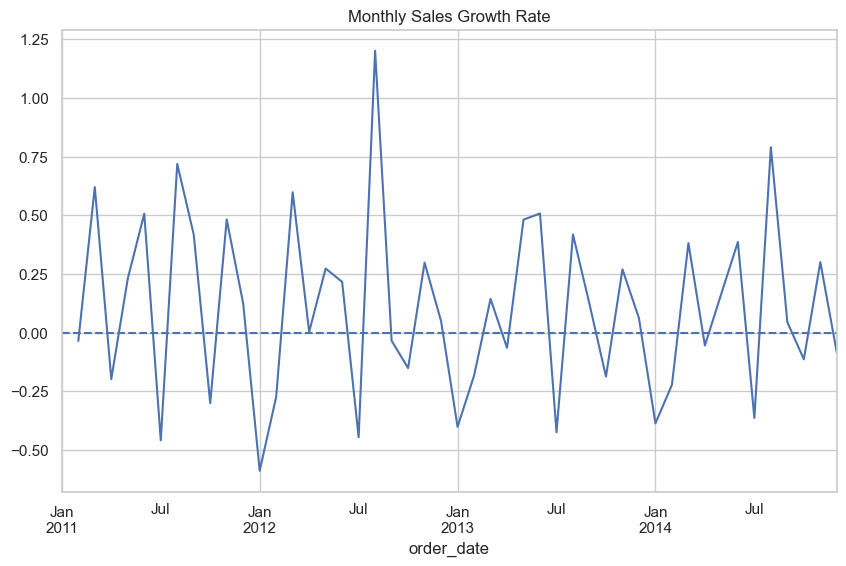

In [46]:
monthly_growth = (monthly_sales.pct_change())

plt.figure(figsize=(10,6))
monthly_growth.plot()
plt.title("Monthly Sales Growth Rate")
plt.axhline(y=0,linestyle="--")
plt.show()

___________________________

Anomaly & Risk Analysis

1. Negetive Profit Orders

In [30]:
negative_profit_orders = orders[orders["profit"] < 0]
negative_profit_orders.shape


(11916, 43)

2. High Sales Anomalies

In [47]:
high_sales_threshold = (orders["sales"].quantile(0.80))
high_sales_anomalies = orders[orders["sales"] > high_sales_threshold]
high_sales_anomalies.head()


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,...,loss_order_flag,total_orders,customer_lifetime_value,avg_order_value,product_total_sales,product_total_profit,regional_total_sales,high_sales_anomaly,extreme_discount_flag,negative_profit_flag
0,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,1,46,12589.95900,273.694761,15455.8125,-981.0675,1.100185e+06,1,0,1
1,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,0,58,19487.96376,335.999375,30041.5482,5455.9482,1.100185e+06,1,0,0
2,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,1,70,16394.46064,234.206581,11087.9550,-270.4350,2.822303e+06,1,0,1
3,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,0,7,3057.21000,436.744286,2832.9600,311.5200,7.837732e+05,1,0,0
4,22732,IN-2013-42360,2013-06-28,2013-07-01,Second Class,JM-15655,Jim Mitchum,Corporate,Sydney,New South Wales,...,0,68,16294.72706,239.628339,13715.3940,3638.2740,1.100185e+06,1,0,0


____________________

Executive Dashboard Table 

1. Executive KPI Table

In [48]:
executive_kpis = pd.DataFrame({"total_revenue": [total_revenue],"total_profit": [total_profit],"profit_margin": [profit_margin],"average_order_value": [average_order_value]})
executive_kpis

,total_revenue,total_profit,profit_margin,average_order_value
0,1.199488e+07,1.394006e+06,0.116217,503.880834


In [49]:
executive_kpis.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/executive_kpis.csv",index=False)
regional_performance.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/regional_performance.csv",index=False)
category_sales.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/category_sales.csv",index=False)

Conclusion
This notebook developed a comprehensive enterprise sales and profitability analytics framework using the Global Superstore dataset.

Key accomplishments include:
* executive KPI engineering
* profitability analysis
* regional performance analytics
* product intelligence analysis
* discount impact analysis
* operational performance analysis
* anomaly detection
* dashboard-ready export generation

The analytical outputs generated in this notebook support:
* executive reporting
* strategic decision-making
* pricing optimization
* operational efficiency analysis
* Power BI dashboard development
* forecasting workflows

This notebook demonstrates enterprise-level sales analytics and profitability intelligence capabilities commonly used in modern business intelligence environments.
